In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred))
    )


def mase(y_true, y_pred, y_train):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_train = np.array(y_train)

    naive_error = np.mean(np.abs(np.diff(y_train)))
    return np.mean(np.abs(y_true - y_pred)) / (naive_error)

def theil_u(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    denominator = np.sqrt(np.mean(y_true ** 2) + np.mean(y_pred ** 2))
    u = rmse / denominator
    return u

# Loading the data
df = pd.read_excel('output_week.xlsx')

# Counting values and aggregating by week
data = df['WEEK'].value_counts().reset_index()
data.columns = ['WEEK', 'DATA']

# Converting week to a date representing the start of the week
data['WEEK_period'] = pd.to_datetime(data['WEEK'] + '-1', format='%G-%V-%u', errors='coerce')
data = data.sort_values('WEEK_period').reset_index(drop=True)

# ------------------------------
# Smoothing (5-week moving average)
# ------------------------------
data['DATA_smooth'] = data['DATA'].rolling(window=5, center=True).mean()
data['DATA_smooth'].fillna(method='bfill', inplace=True)
data['DATA_smooth'].fillna(method='ffill', inplace=True)

# Log transformation of the data
data['y'] = np.log1p(data[['DATA_smooth']])

# ------------------------------
# 6️⃣ Prepare X and y
# ------------------------------

y = data['y'].values.astype(np.float32)

# ------------------------------
# 7️⃣ Train/test split
# ------------------------------
split = int(len(y) * 0.7)
y_train, y_test = y[:split], y[split:]

/var/folders/36/lb3mdhtj2lldbybnz877q_hr0000gn/T/ipykernel_3440/4194531609.py:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['DATA_smooth'].fillna(method='bfill', inplace=True)
/var/folders/36/lb3mdhtj2lldbybnz877q_hr0000gn/T/ipykernel_3440/4194531609.py:45: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['DATA_smooth'].fillna(method='bfill', inplace=True)
/var/folders/36/lb3mdhtj2lldbybnz877q_hr0000gn/T/ipykernel_3440/419453160

RMSE: 0.2513
R2: -0.0333
MAPE (normalized): 9.53%
MAPE (real scale): 25.05%
SMAPE: 9.17%
MASE: 2.7728
Theil's U1: 0.07782580921330844


/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


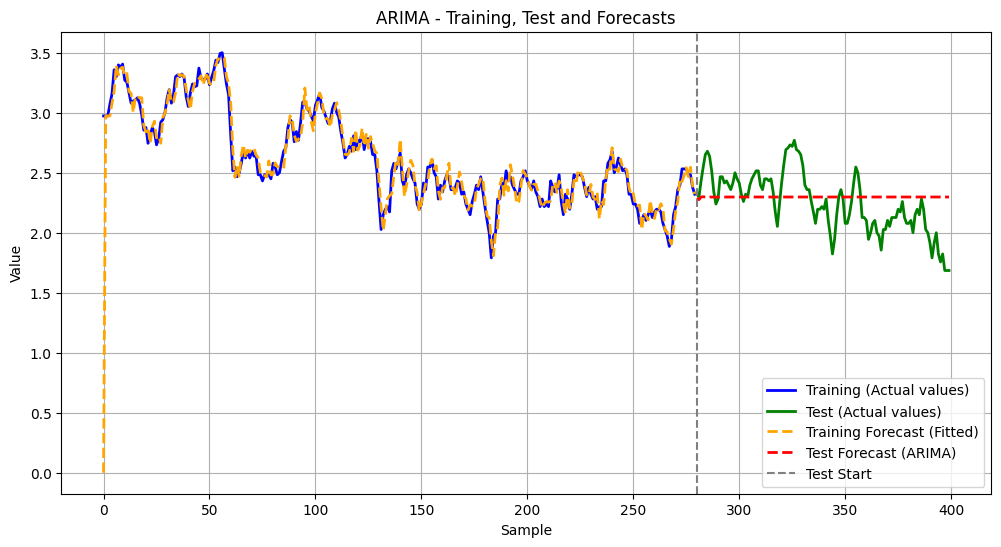

In [ ]:
# 1. ARIMA model fitting
model_arima = ARIMA(y_train, order=(4, 1, 5))
model_fit_arima = model_arima.fit()

# 2. Forecast
predictions_arima = model_fit_arima.forecast(steps=len(y_test))

y_pred = predictions_arima

# ------------------------------
# Metrics
# ------------------------------
smape_value = smape(y_test, y_pred)
mase_value = mase(y_test, y_pred, y_train)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Normalized MAPE
mape = np.mean(np.abs((y_test - y_pred) / (y_test))) * 100

# Real-scale MAPE
y_test_real = np.expm1(y_test.reshape(-1, 1)).flatten()
y_pred_real = np.expm1(y_pred.reshape(-1, 1)).flatten()

mape_real = np.mean(np.abs((y_test_real - y_pred_real) / (y_test_real))) * 100

u1 = theil_u(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")
print(f"MAPE (normalized): {mape:.2f}%")
print(f"MAPE (real scale): {mape_real:.2f}%")
print(f"SMAPE: {smape_value:.2f}%")
print(f"MASE: {mase_value:.4f}")
print("Theil's U1:", u1)

fitted = model_fit_arima.fittedvalues
# in-sample (training) fitted values

plt.figure(figsize=(12, 6))

# indices
idx_train = np.arange(len(y_train))
idx_test = np.arange(len(y_train), len(y_train) + len(y_test))

# ---------------------------
#  ACTUAL VALUES
# ---------------------------

# training actual values
plt.plot(idx_train, y_train,
         label='Training (Actual values)',
         color='blue', linewidth=2)

# test actual values
plt.plot(idx_test, y_test,
         label='Test (Actual values)',
         color='green', linewidth=2)

# ---------------------------
# FORECASTS
# ---------------------------

# training fitted values
plt.plot(idx_train, fitted,
         label='Training Forecast (Fitted)',
         color='orange', linestyle='--', linewidth=2)

# test forecasts
plt.plot(idx_test, y_pred,
         label='Test Forecast (ARIMA)',
         color='red', linestyle='--', linewidth=2)

# ---------------------------
# SPLIT LINE
# ---------------------------

plt.axvline(x=len(y_train), color='gray', linestyle='--', label='Test Start')

plt.title('ARIMA - Training, Test and Forecasts')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
# -----------------------------------
# Auto-ARIMA model selection
# -----------------------------------
from pmdarima import auto_arima

auto_model = auto_arima(
    y_train,
    seasonal=False,      # use True if you want SARIMA
    stepwise=True,       # faster search
    suppress_warnings=True,
    error_action="ignore",
    trace=True
)

print(auto_model.summary())

# Best ARIMA order selected automatically
best_order = auto_model.order
print("Best ARIMA order:", best_order)

# -----------------------------------
# Fit final ARIMA model with selected order
# -----------------------------------
model_arima = ARIMA(y_train, order=best_order)
model_fit_arima = model_arima.fit()

# -----------------------------------
# Forecast
# -----------------------------------
predictions_arima = model_fit_arima.forecast(steps=len(y_test))
y_pred = predictions_arima

/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: F

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-568.735, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-514.108, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-514.440, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-513.999, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-515.941, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-513.052, Time=0.06 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-527.866, Time=0.10 sec


/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-533.915, Time=0.18 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=-555.910, Time=0.19 sec


/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(5,1,5)(0,0,0)[0]             : AIC=-622.372, Time=0.33 sec


/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(5,1,4)(0,0,0)[0]             : AIC=-596.503, Time=0.21 sec

Best model:  ARIMA(4,1,5)(0,0,0)[0]          
Total fit time: 5.309 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  280
Model:               SARIMAX(4, 1, 5)   Log Likelihood                 321.920
Date:                Sat, 06 Jun 2026   AIC                           -623.839
Time:                        11:45:46   BIC                           -587.527
Sample:                             0   HQIC                          -609.273
                                - 280                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1785      0.075      2.366      0.018       0.031 

/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
